In [23]:
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt

# 환경 설정
num_states = 5
num_actions = 2
gamma = 0.99

# Q-네트워크 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(num_states,)),
    tf.keras.layers.Dense(num_actions, activation='linear')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse')

# 환경 정의
def step(state, action):
    if action == 0:  # 왼쪽으로 이동
        new_state = max(state - 1, 0)
    else:  # 오른쪽으로 이동
        new_state = min(state + 1, num_states - 1)
    reward = 1 if new_state == num_states - 1 else 0  # 목표 지점에 도달하면 보상 1, 그렇지 않으면 0
    return new_state, reward

# 학습
num_episodes = 20

for episode in range(num_episodes):
    print(episode)
    state = 0
    done = False

    while not done:
        # 무작위로 액션 선택
        action = random.randint(0, num_actions - 1)

        # 액션 수행
        next_state, reward = step(state, action)

        # 상태를 원-핫 인코딩
        state_encoded = np.eye(num_states)[state]
        next_state_encoded = np.eye(num_states)[next_state]

        # 학습
        target_q = reward + gamma * np.max(model.predict(next_state_encoded.reshape(1, -1)))
        model.fit(state_encoded.reshape(1, -1), np.array([[target_q]]), epochs=1, verbose=0)

        state = next_state
        done = state == num_states - 1

        
    
# 결과 시각화
q_values_left = []
q_values_right = []

for state in range(num_states):
    state_encoded = np.eye(num_states)[state]
    q_values = model.predict(state_encoded.reshape(1, -1))[0]
    q_values_left.append(q_values[0])
    q_values_right.append(q_values[1])

plt.plot(range(num_states), q_values_left, label='Qvalue when move left')
plt.plot(range(num_states), q_values_right, label='Q value when move right')
plt.xlabel('state')
plt.ylabel('Q-value')
plt.legend()
plt.show()


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "C:\Users\HYKP\miniconda3\envs\bistel\lib\site-packages\IPython\core\interactiveshell.py", line 3444, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\HYKP\AppData\Local\Temp/ipykernel_33052/1889438238.py", line 50, in <module>
    model.fit(state_encoded.reshape(1, -1), np.array([[target_q]]), epochs=1, verbose=0)
  File "C:\Users\HYKP\miniconda3\envs\bistel\lib\site-packages\keras\engine\training.py", line 1134, in fit
    data_handler = data_adapter.get_data_handler(
  File "C:\Users\HYKP\miniconda3\envs\bistel\lib\site-packages\keras\engine\data_adapter.py", line 1383, in get_data_handler
    return DataHandler(*args, **kwargs)
  File "C:\Users\HYKP\miniconda3\envs\bistel\lib\site-packages\keras\engine\data_adapter.py", line 1138, in __init__
    self._adapter = adapter_cls(
  File "C:\Users\HYKP\miniconda3\envs\bistel\lib\site-packages\keras\engine\data_adapter.py", line 286, in __init__
    indices_datase

TypeError: object of type 'NoneType' has no len()

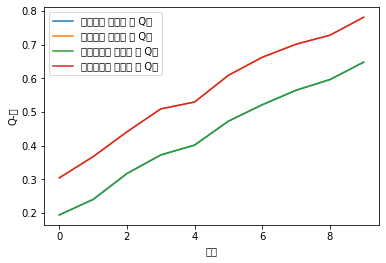

In [34]:
import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt

# 환경 설정
num_states = 5
num_actions = 2
gamma = 0.99

# Q-네트워크 생성
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(num_states,)),
    tf.keras.layers.Dense(num_actions, activation='linear')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='mse')

# 환경 정의
def step(state, action):
    if action == 0:  # 왼쪽으로 이동
        new_state = max(state - 1, 0)
    else:  # 오른쪽으로 이동
        new_state = min(state + 1, num_states - 1)
    reward = 1 if new_state == num_states - 1 else 0  # 목표 지점에 도달하면 보상 1, 그렇지 않으면 0
    return new_state, reward

import numpy as np
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ... (이전 코드와 동일)

# 실시간 시각화를 위한 함수
def plot_q_values(q_values_left, q_values_right):
    clear_output(wait=True)
    plt.plot(q_values_left, label='왼쪽으로 이동할 때 Q값')
    plt.plot(q_values_right, label='오른쪽으로 이동할 때 Q값')
    plt.xlabel('상태')
    plt.ylabel('Q-값')
    plt.legend()
    plt.show()

# 학습
num_episodes = 10
q_values_left = []
q_values_right = []

for episode in range(num_episodes):
    state = 0
    done = False

    while not done:
        # 무작위로 액션 선택
        action = random.randint(0, num_actions - 1)

        # 액션 수행
        next_state, reward = step(state, action)

        # 상태를 원-핫 인코딩
        state_encoded = np.eye(num_states)[state]
        next_state_encoded = np.eye(num_states)[next_state]

        # 학습
        target_q = reward + gamma * np.max(model.predict(next_state_encoded.reshape(1, -1)))
        model.fit(state_encoded.reshape(1, -1), np.array([[target_q]]), epochs=1, verbose=0)

        state = next_state
        done = state == num_states - 1

    # 에피소드 종료 후 Q-값 저장
    q_values_left.append(model.predict(state_encoded.reshape(1, -1))[0])
    q_values_right.append(model.predict(state_encoded.reshape(1, -1))[0])
    

    # 실시간 시각화
    plot_q_values(q_values_left, q_values_right)

In [41]:
model.predict(state_encoded.reshape(1,-1))

array([[0.6484131 , 0.78184587]], dtype=float32)